In [4]:
import pandas as pd
import numpy as np

courses = pd.read_csv('courses.csv')
students = pd.read_csv('students.csv')
nov = pd.read_csv('reg-month1.csv')
dec = pd.read_csv('reg-month2.csv')
matches = pd.read_csv('matches.csv')
delivery = pd.read_csv('deliveries.csv')
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [6]:
# find the total revenue generated
regs = pd.concat([nov,dec],ignore_index=True)
studs = regs.merge(courses,how='inner',on='course_id')
revenue = studs['price'].sum()
print(revenue)

154247


In [9]:
# find month by month revenue
tf = pd.concat([nov,dec],keys=['Nov','Dec']).reset_index()
tf.merge(courses,how='inner',on='course_id').groupby('level_0')['price'].sum()

level_0
Dec    65072
Nov    89175
Name: price, dtype: int64

In [12]:
# 3. Print the registration table
# cols -> name -> course -> price

regstud = regs.merge(students,how='inner',on='student_id')
result = regstud.merge(courses,how='inner',on='course_id')
result[['name','course_name','price']]


,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


course_name
plotly               3495
pandas               4396
sql                  6998
ms sxcel             7995
power bi            11394
pyspark             14994
tableau             17493
python              22491
data analysis       24995
machine learning    39996
Name: price, dtype: int64


<Axes: xlabel='course_name'>

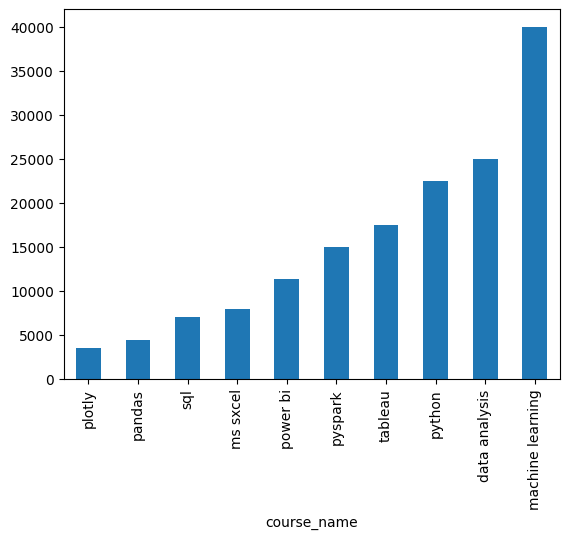

In [15]:
# plot bar chart for course revenue
table = regs.merge(courses,how='inner',on='course_id').groupby('course_name')['price'].sum().sort_values(ascending=True)
print(table)
table.plot(kind='bar')


In [18]:
# students who purchased a course in both nov and dec
common_student_id = np.intersect1d(nov['student_id'],dec['student_id'])
common_student_id
students[students['student_id'].isin(common_student_id)]


,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18
